In [1]:
library(shazam)

db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_C_insilico_102400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

dist <- dist[!is.na(dist)]

out <- findThreshold(dist, method = "density")

out@threshold

Loading required package: ggplot2

Warning message:
"replacing previous import 'S4Arrays::makeNindexFromArrayViewport' by 'DelayedArray::makeNindexFromArrayViewport' when loading 'SummarizedExperiment'"


To cite the SHazaM package in publications, please use:

  Gupta N, Vander Heiden J, Uduman M, Gadala-Maria D, Yaari G,
  Kleinstein S (2015). "Change-O: a toolkit for analyzing large-scale B
  cell immunoglobulin repertoire sequencing data." _Bioinformatics_,
  1-3. doi:10.1093/bioinformatics/btv359
  <https://doi.org/10.1093/bioinformatics/btv359>.

To cite the selection analysis methods, please use:

  Yaari G, Uduman M, Kleinstein S (2012). "Quantifying selection in
  high-throughput Immunoglobulin sequencing data sets." _Nucleic acids
  research_, *40*(17), e134. doi:10.1093/nar/gks457
  <https://doi.org/10.1093/nar/gks457>.

To cite the HH_S5F model and the targeting model generation methods,
please use:

  Yaari G, Vander Heiden J, Uduman M, Gadala-Maria D, Gupta N, Stern J,
  

In [18]:
library(shazam)

# 1. Cargar tu base de datos
db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_C_insilico_6400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

# 2. Calcular distancias (Tu código base)
dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

# Limpiar los NA para el análisis
dist <- dist[!is.na(dist)]

# 3. ADAPTACIÓN A GMM: 
# Reemplazamos "density" por "gmm". 
# Usamos el modelo "norm-norm" y el corte "optimal" para hallar el umbral matemático.
out <- findThreshold(
  dist, 
  method = "gmm", 
  model = "norm-norm", 
  cutoff = "optimal"
)

# 4. Extraer el umbral calculado por el modelo de mixtura
threshold_final <- out@threshold

# Mostrar el resultado en la consola
print(paste("El umbral calculado por GMM es:", threshold_final))

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"


[1] "El umbral calculado por GMM es: 0.287091854804257"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0417  0.2292  0.2857  0.2867  0.3333  0.6111 

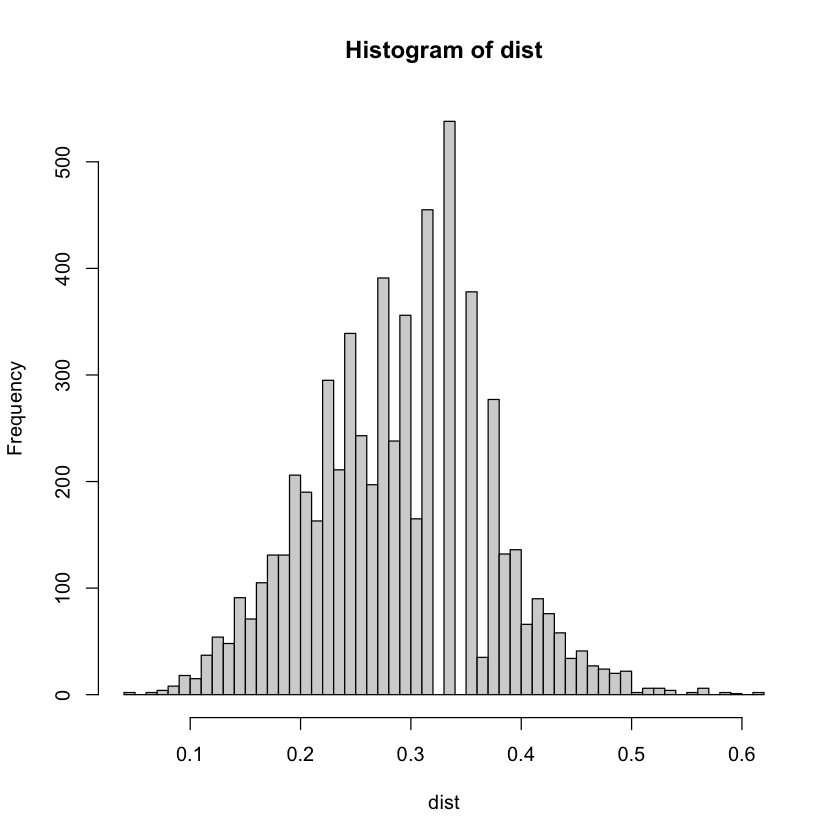

In [19]:
hist(dist, breaks = 50)
summary(dist)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


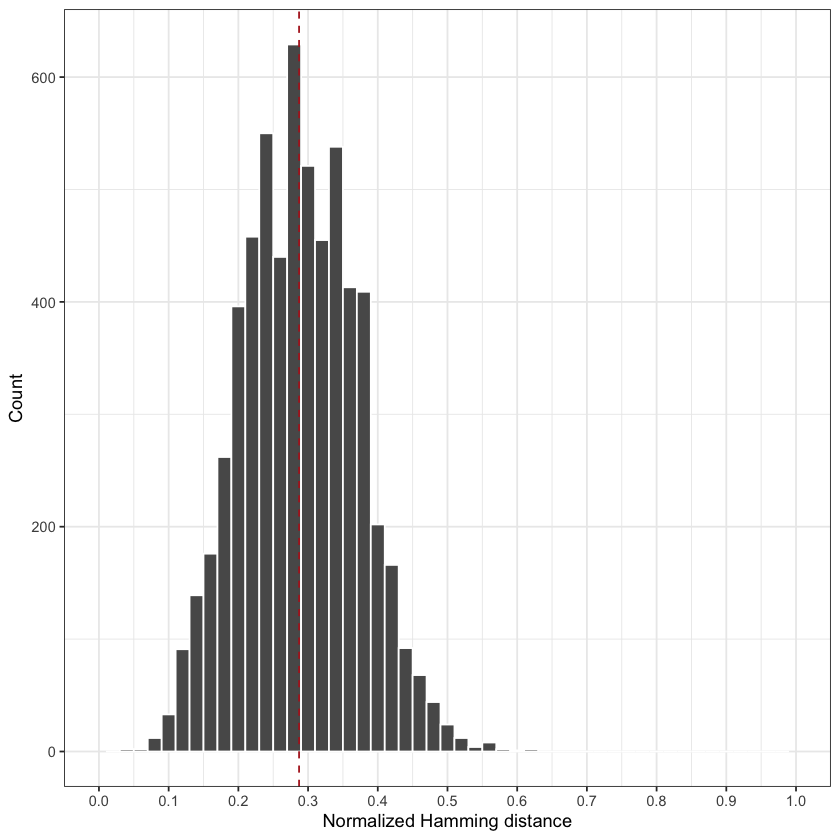

In [20]:
library(ggplot2)

threshold <- out@threshold

p1 <- ggplot(data.frame(dist = dist), aes(x = dist)) +
  geom_histogram(
    color = "white",
    binwidth = 0.02
  ) +
  geom_vline(
    xintercept = threshold,
    color = "firebrick",
    linetype = 2
  ) +
  labs(
    x = "Normalized Hamming distance",
    y = "Count"
  ) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.1),
    limits = c(0, 1)
  ) +
  theme_bw()

p1